# Zadanie domowe 2

W ramach zadania należało udostępnić model przy pomocy jednego z narzędzi:
- BentoML
- TorchServe
- NVIDIA Triton

In [1]:
from pytorch_lightning import seed_everything
seed_everything(121, workers=True)

Seed set to 121


121

## Zbiór danych

Obrany został zbiór danych z Kaggla: https://www.kaggle.com/datasets/imsparsh/flowers-dataset/

Zawiera on zdjęcia kwiatów przydzielonych do 5 kategorii:
- daisy (stokrotka)
- dandelion (mniszek)
- rose (róża)
- sunflower (słonecznik)
- tulip (tulipan)

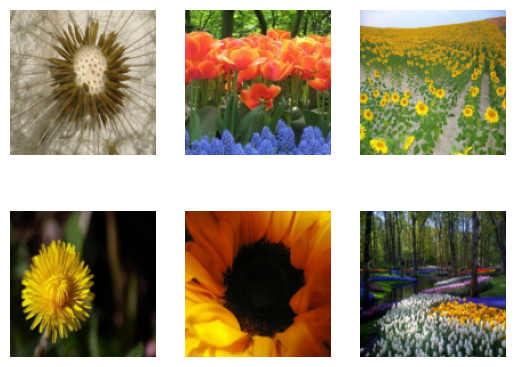

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torchvision import transforms

path = os.path.join("Dataset", "test")
img_set = [img for img in os.listdir(path) if img.endswith('.jpg')]
img_plot = np.array([])
for i, img_path in enumerate(img_set[:6]):
    img = Image.open(os.path.join(path, img_path))
    plt.subplot(2,3,i+1)
    plt.axis('off')
    plt.imshow(transforms.Resize((128,128))(img))
plt.show()

In [3]:
from torchvision import transforms

transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor()
        ])

In [4]:
from utils import LightingData, LightingModel, PredictDataSet

data = LightingData(
        dataset_dir = 'Dataset',
        batch_size = 16,
        num_workers = 4,
        transform = transform
    )

In [5]:
from pytorch_lightning.callbacks import ModelCheckpoint

lightning_callback = [ModelCheckpoint(
        monitor='val_loss',
        dirpath='checkpoints',
        filename='best-checkpoint'
    )]

In [6]:
from pytorch_lightning.loggers import CSVLogger, WandbLogger

csv_logger = CSVLogger("logs", name="test")
wandb_logger = WandbLogger(project="pytorch-lightning")
loggers = [csv_logger, wandb_logger]

In [7]:
model = LightingModel()

In [8]:
import pytorch_lightning as pl

trainer = pl.Trainer(max_epochs = 15, logger = loggers, callbacks=lightning_callback, deterministic=True, val_check_interval=0.2)
trainer.fit(model, data)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: kacper7866 (kacper7866-poznan-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/home/kacper/Pulpit/Programowanie_Python/.venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/kacper/Pulpit/Programowanie_Python/NUM/checkpoints exists and is not empty.

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | linear1 | Linear           | 17.1 M | train
1 | conv1   | Conv2d           | 2.7 K  | train
2 | conv2   | Conv2d           | 166 K  | train
3 | maxpool | MaxPool2d        | 0      | train
4 | dropout | Dropout          | 0      | train
5 | linear2 | Linear           | 500    | train
6 | loss_fn | CrossEntropyLoss | 0      | train
7 | cnn     | Sequential       | 17.3 M | train
-----------------------------------------------------
17.3 M    Trainable params
0         Non-trainable params
17.3 M    Total params
69.106    Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Epoch 14: 100%|██████████| 138/138 [05:21<00:00,  0.43it/s, v_num=8yom]    

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 138/138 [05:21<00:00,  0.43it/s, v_num=8yom]


# Model deployment
Do wystawienia modelu wykorzystany został framework BentoML.

In [9]:
import bentoml

saved_model = bentoml.pytorch_lightning.save_model("CNN",model=model)

Converting 'CNN' to lowercase: 'cnn'.
